# **Introduction à l'Apprentissage Supervisé et à la Classification**

### Introduction

Dans ce notebook, nous explorerons les bases de l’**apprentissage supervisé**, une méthode fondamentale du Machine Learning où un modèle apprend à prédire une valeur cible en s’appuyant sur des données déjà étiquetées. Nous nous concentrerons spécifiquement sur la **classification**, une tâche consistant à prédire la catégorie ou la classe d'une observation en fonction de ses caractéristiques. 

Pour bien comprendre ces concepts, nous aborderons les étapes clés du workflow de l’apprentissage supervisé, de la préparation des données jusqu'à l'évaluation des modèles. Nous appliquerons ensuite ces notions sur un dataset réel, le célèbre **dataset Iris**, qui servira de base pour illustrer chaque étape, construire et évaluer plusieurs modèles de classification.

### Objectifs du notebook

- Découvrir les concepts théoriques de l’**apprentissage supervisé** et de la **classification**.
- Comprendre les étapes d’un projet de Machine Learning supervisé, depuis l’exploration des données jusqu’à l’évaluation des modèles.
- Mettre en pratique ces concepts en entraînant différents modèles pour prédire des classes sur des données réelles.

Ce notebook vous apportera une compréhension concrète de la classification, un pilier essentiel du Machine Learning, en vous guidant pas à pas, de la théorie à la pratique.

---

## **Introduction à l’Apprentissage Supervisé**

### **Définition de l'Apprentissage Supervisé**

L'apprentissage supervisé est une branche fondamentale du Machine Learning où le modèle apprend à partir de données déjà étiquetées, c’est-à-dire des données pour lesquelles nous connaissons les réponses correctes. L'objectif est de permettre au modèle d’**apprendre des relations** entre les données d’entrée (appelées caractéristiques ou *features*) et les réponses (*target*) de façon à pouvoir **prédire la réponse** pour de nouvelles données inconnues.

**Exemples d'applications d'apprentissage supervisé :**
- Détection de spam (prédire si un email est spam ou non).
- Prédiction du prix de l’immobilier (évaluer la valeur d’une maison en fonction de ses caractéristiques).


### **Types de Tâches Supervisées**

L'apprentissage supervisé inclut principalement deux types de tâches :

- **Classification** : Prédire une **catégorie** ou **classe**. Exemple : classifier un email comme spam ou non-spam, ou prédire l'espèce d'une fleur en fonction de ses caractéristiques (longueur et largeur de pétales, etc.).
- **Régression** : Prédire une **valeur continue**. Exemple : estimer le prix d'une maison en fonction de ses caractéristiques, ou prédire le revenu annuel d'un individu.

> Ces tâches dépendent du type de variable cible (*target*). Si la cible est une catégorie, c'est une classification. Si la cible est une valeur continue, c'est une régression.

#### Quiz : Tâche de Régression ou Classification ?

Pour chaque scénario ci-dessous, indiquez s’il s’agit d’une tâche de **régression** ou de **classification**.

1. **Prévision des ventes** : Une entreprise souhaite prédire le nombre d’unités qu’elle vendra de son nouveau produit au cours du prochain mois.
   - **Régression** ou **Classification** ?


2. **Détection d'email spam** : Un modèle doit classifier les emails comme étant soit du spam, soit du non-spam.
   - **Régression** ou **Classification** ?


3. **Prédiction du prix de l'immobilier** : Un modèle est utilisé pour estimer la valeur d’une maison en fonction de ses caractéristiques (taille, nombre de chambres, localisation).
   - **Régression** ou **Classification** ?


4. **Diagnostic médical** : Un modèle est entraîné pour prédire si un patient est atteint ou non d'une certaine maladie en fonction de ses antécédents médicaux et de ses résultats d'examens.
   - **Régression** ou **Classification** ?


5. **Prédiction du revenu annuel** : Un modèle doit estimer le revenu annuel d’un individu en fonction de plusieurs caractéristiques démographiques et professionnelles.
   - **Régression** ou **Classification** ?


6. **Classification des genres musicaux** : Un modèle est utilisé pour classifier des morceaux de musique en fonction de leur genre (par exemple, rock, jazz, classique).
   - **Régression** ou **Classification** ?


7. **Estimation de la température** : Un modèle est utilisé pour prédire la température moyenne d’une ville pour le jour suivant en fonction des données météorologiques récentes.
   - **Régression** ou **Classification** ?


8. **Prévision des scores scolaires** : Un modèle est utilisé pour prédire le score final d’un étudiant en fonction de son temps d’étude et de ses notes passées.
   - **Régression** ou **Classification** ?


9. **Détection de fraude** : Une banque utilise un modèle pour identifier les transactions suspectes et les classer comme « frauduleuses » ou « non frauduleuses ».
   - **Régression** ou **Classification** ?


10. **Prédiction du taux de satisfaction client** : Une entreprise souhaite prédire si un client sera « satisfait », « neutre » ou « insatisfait » après avoir utilisé un service.
    - **Régression** ou **Classification** ?


---
**Réponse :**

1. Régression — on prédit un nombre d'unités (valeur continue).
2. Classification — deux catégories : spam / non-spam.
3. Régression — on estime un prix (valeur continue).
4. Classification — malade / non malade.
5. Régression — on estime un revenu (valeur continue).
6. Classification — plusieurs genres : rock, jazz, classique (multiclasse).
7. Régression — on prédit une température (valeur continue).
8. Régression — on prédit un score (valeur continue).
9. Classification — frauduleuse / non frauduleuse.
10. Classification — satisfait / neutre / insatisfait (multiclasse).


### **Composantes de l’Apprentissage Supervisé**

Pour bien comprendre l'apprentissage supervisé, il est essentiel de connaître les composantes principales d'un dataset et leur rôle :

- **Features (Caractéristiques)** : Les variables d’entrée qui décrivent chaque observation dans le dataset (par exemple, la longueur et la largeur des pétales pour classifier une fleur).
- **Target (Cible)** : La variable que nous essayons de prédire à partir des caractéristiques. Dans notre cas, la cible pourrait être l'espèce de la fleur (setosa, versicolor, virginica).
- **Training Data (Données d’Entraînement)** : Sous-ensemble du dataset utilisé pour entraîner le modèle, afin qu'il apprenne à associer les caractéristiques à la cible.
- **Test Data (Données de Test)** : Sous-ensemble du dataset utilisé pour évaluer le modèle après l’entraînement et mesurer sa capacité de généralisation sur des données nouvelles.



## **Workflow Général en Apprentissage Supervisé**

Le workflow d'un projet de Machine Learning supervisé comporte plusieurs étapes. Voici une représentation visuelle du processus :

```markdown

   ┌───────────────┐      ┌───────────────┐      ┌───────────────┐       ┌───────────────┐
   │   Dataset     │ ---> │   Exploration │ ---> │ Preprocessing │ --->  │   Splitting   │ 
   └───────────────┘      └───────────────┘      └───────────────┘       └───────────────┘  
                                                                               │                       
                                                                  └─────────────────────────────┘
                                                                      │                   │ 
                                                                      ▼                   ▼
                                                            ┌───────────────┐         ┌───────────────┐
                                                            │ Training Data │         │   Test Data   │
                                                            └───────────────┘         └───────────────┘
                                                                   └─────────────────────────────┘
                                                                       │                   │ 
                                                                       ▼                   ▼
                                                           ┌────────────────┐          ┌──────────────────┐
                                                           │ Model Training │          │ Model Evaluation │
                                                           │  (sur Train)   │          │    (sur Test)    │
                                                           └────────────────┘          └──────────────────┘





```


**Étapes du Workflow :**

1. **Dataset** : Point de départ, le dataset contient les caractéristiques (*features*) et la cible (*target*) pour chaque observation.
   
2. **Exploration** : Analyse et visualisation des données pour identifier leur structure, leur distribution et des caractéristiques spécifiques. Cela permet de mieux comprendre les données avant de les transformer.

3. **Prétraitement** : Préparation des données en appliquant des transformations comme la gestion des valeurs manquantes, l’encodage des variables catégorielles et la normalisation si nécessaire. Ces étapes assurent la qualité et la cohérence des données pour l’entraînement du modèle.

4. **Splitting (Division)** : Division du dataset en **Training Data** (données d’entraînement) et **Test Data** (données de test) pour garantir une évaluation fiable des performances du modèle. Cette séparation permet d'entraîner le modèle sur une partie des données, puis de le tester sur des données qu'il n’a jamais vues.

5. **Model Training (Entraînement du Modèle)** : Entraînement du modèle sur l'ensemble des données d’entraînement (Training Data). L’objectif est que le modèle "apprenne" les relations entre les caractéristiques et la cible à partir des exemples.

6. **Model Evaluation (Évaluation du Modèle)** : Test du modèle sur l’ensemble des données de test (Test Data) en utilisant des métriques adaptées à la tâche de classification, telles que l’exactitude, le rappel, et le F1-score. Cette étape permet de mesurer la capacité du modèle à généraliser et à faire des prédictions fiables sur de nouvelles données.

> **Note :** Ce workflow assure que le modèle apprend à partir des données d’entraînement sans surapprendre, tout en offrant une évaluation réaliste de ses performances sur de nouvelles données.

---

## **Introduction a la Classification**

### Définition de la Classification

La **classification** est une tâche fondamentale en Machine Learning qui consiste à assigner une **catégorie** ou **classe** à une observation en fonction de ses caractéristiques. Le modèle de classification apprend à partir de données annotées pour reconnaître des motifs et peut ensuite prédire la classe d’une nouvelle donnée. C’est un type de tâche d’**apprentissage supervisé**, car les données d'entraînement contiennent les labels de classe connus.

<img src="..\assets\classification.png" alt="classification.png" width="400" height="400">

### Types de Classification

Il existe différents types de classification en fonction du nombre et de la nature des classes :

1. **Classification Binaire** : Le modèle attribue une observation à l’une des **deux classes possibles**. Exemple : détection d'email comme **spam** ou **non-spam**.
2. **Classification Multiclasse** : Le modèle attribue une observation à l’une de **plusieurs classes**. Exemple : classifier une image comme représentant un **chat**, un **chien**, ou un **oiseau**.
3. **Classification Multi-étiquettes** : Une observation peut appartenir à **plusieurs classes simultanément**. Exemple : étiqueter une image qui pourrait contenir à la fois **une personne** et **un animal**.


### Exemple de Classification

Imaginons un modèle de classification pour filtrer les emails en **Spam** ou **Non-Spam**. Le modèle examine les caractéristiques des emails (par exemple, la présence de certains mots) et apprend à prédire si un nouvel email est probablement du spam.

> **Exemple de Dataset** :

| Email               | Contient "Offre" ? | Contient "Promo" ? | Spam ? |
|---------------------|--------------------|---------------------|--------|
| "Promo spéciale !" | Oui                | Oui                | Oui    |
| "Rendez-vous..."   | Non                | Non                | Non    |
| "Offre de prêt"    | Oui                | Non                | Oui    |

Dans cet exemple simplifié, le modèle apprend que les mots-clés "Offre" et "Promo" sont associés aux emails de spam et utilise cette information pour classer de nouveaux emails.

---
## Introduction au Dataset Iris

Dans cette étape, nous allons introduire le dataset **Iris**, un dataset classique pour la classification en apprentissage supervisé.

Le dataset Iris contient 150 observations réparties en trois classes de fleurs : **Setosa**, **Versicolor**, et **Virginica**. Chaque observation comporte quatre caractéristiques principales mesurées en centimètres : la longueur et la largeur des pétales, ainsi que la longueur et la largeur des sépales.

Les colonnes du dataset sont :

1. `sepal_length` : Longueur du sépale
2. `sepal_width` : Largeur du sépale
3. `petal_length` : Longueur du pétale
4. `petal_width` : Largeur du pétale
5. `species` : La classe de la fleur (Setosa, Versicolor, Virginica)

L'objectif est de prédire la classe d'une fleur en fonction de ses caractéristiques.

![Iris_Flowers](..\assets\Iris_Flowers.png)



---
## Étape 1 : Charger le Dataset Iris

Nous allons charger le dataset Iris, qui est disponible directement dans `sklearn`. `load_iris()` permet de récupérer les données et les informations nécessaires pour une analyse complète.

### Instructions :

1. **Importez les bibliothèques nécessaires** :
   - **`pandas`** pour la manipulation des données.
   - **`matplotlib.pyplot`** et **`seaborn`** pour la visualisation.
   - **`sklearn.datasets`** pour charger le dataset Iris intégré.

2. **Charger le Dataset avec `load_iris()`** :
   - Utilisez `load_iris()` de `sklearn.datasets` pour charger les données. Cette fonction renvoie un objet `Bunch`, similaire à un dictionnaire, contenant les données et des informations associées.

3. **Explorer les Attributs du Dataset** :
   - **`data`** : Contient les valeurs des caractéristiques pour chaque observation (longueur/largeur des sépales et pétales).
   - **`target`** : Contient les labels de classe sous forme de valeurs numériques (0, 1, 2) correspondant aux trois espèces d’iris.
   - **`feature_names`** : Liste des noms des caractéristiques.
   - **`target_names`** : Liste des noms des classes (Setosa, Versicolor, Virginica).
   - **`DESCR`** : Une description textuelle du dataset, expliquant ses caractéristiques et sa structure.

4. **Créer un DataFrame avec les Caractéristiques et les Labels** :
   - Utilisez `data` et `feature_names` pour créer un DataFrame `pandas`. Les noms des caractéristiques serviront de noms de colonnes.
   - Ajoutez une colonne `species` pour les labels de classe, en utilisant `target`. Pour une meilleure lisibilité, mappez chaque valeur numérique de `target` aux noms de classes correspondants (`target_names`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df["species_name"] = df["species"].map(dict(enumerate(iris.target_names)))
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


---
## Étape 2 : Exploration des Données (EDA) avec le Dataset Iris

L’exploration des données, ou **Exploratory Data Analysis (EDA)**, est une étape essentielle pour mieux comprendre la structure, les relations, et les particularités des données avant de construire un modèle. Cette étape permet de :

- Identifier la distribution des données.
- Détecter les éventuels problèmes, comme les valeurs manquantes ou les anomalies.
- Comprendre les relations entre les caractéristiques et les classes cibles.

**Instructions :**

1. **Afficher les premières lignes du DataFrame**  
   Utilisez la méthode `.head()` sur le DataFrame pour afficher les cinq premières lignes. Cette vue rapide vous donnera un aperçu de la structure et des types de données des colonnes.

In [2]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


> **Question :** Que remarquez-vous dans les colonnes et les types de données du DataFrame ? Les noms des caractéristiques sont-ils clairs ?


---
**Réponse :** Les 4 premières colonnes sont numériques (`float`) et correspondent aux mesures en cm (longueur/largeur des sépales et pétales). `species` est la classe encodée en nombres (0, 1, 2) et `species_name` en donne le nom (setosa, versicolor, virginica). Les noms de colonnes sont clairs.


2. **Vérifier les informations de base sur le DataFrame**  
   Utilisez la méthode `.info()` sur le DataFrame pour afficher des informations générales comme le type de chaque colonne, la présence éventuelle de valeurs manquantes et le nombre total d’observations.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


> **Question :** Y a-t-il des valeurs manquantes dans ce dataset ? Quel type de données chaque colonne contient-elle ?


---
**Réponse :** Aucune valeur manquante : `.info()` indique 150 valeurs non-nulles pour chaque colonne. Les 4 caractéristiques sont en `float64`, `species` en `int64`, et `species_name` en `object` (texte).


3. **Examiner les statistiques descriptives**  
   Utilisez la méthode `.describe()` pour afficher les statistiques de base (moyenne, écart-type, minimum, maximum) de chaque caractéristique numérique afin de comprendre leur distribution.

In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


> **Question :** Les caractéristiques ont-elles des plages de valeurs similaires ou différentes ? Que pouvez-vous en déduire quant à la variabilité des données ?


---
**Réponse :** Les plages sont différentes d'une caractéristique à l'autre : les pétales (`petal length` 1,0→6,9 cm, `petal width` 0,1→2,5 cm) varient beaucoup plus que les sépales (`sepal width` 2,0→4,4 cm). L'écart-type de `petal length` (≈1,77) est le plus élevé, celui de `sepal width` le plus faible (≈0,44). La variabilité est donc inégale entre les caractéristiques.


4. **Analyser la répartition des classes**  
   Utilisez la méthode `.value_counts()` sur la colonne des labels pour compter le nombre d’observations dans chaque classe.

In [5]:
df["species_name"].value_counts()

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

> **Question :** Comment les classes sont-elles réparties ? Y a-t-il un équilibre entre elles, ou l’une des classes est-elle sur-représentée ?


---
**Réponse :** Les classes sont parfaitement équilibrées : 50 observations pour chacune des 3 espèces (setosa, versicolor, virginica). Aucune classe n'est sur-représentée.


5. **Visualiser la distribution des caractéristiques**  
   Utilisez des graphiques comme `sns.histplot()` ou `sns.boxplot()` pour créer des histogrammes ou des boxplots et visualiser la distribution de chaque caractéristique.

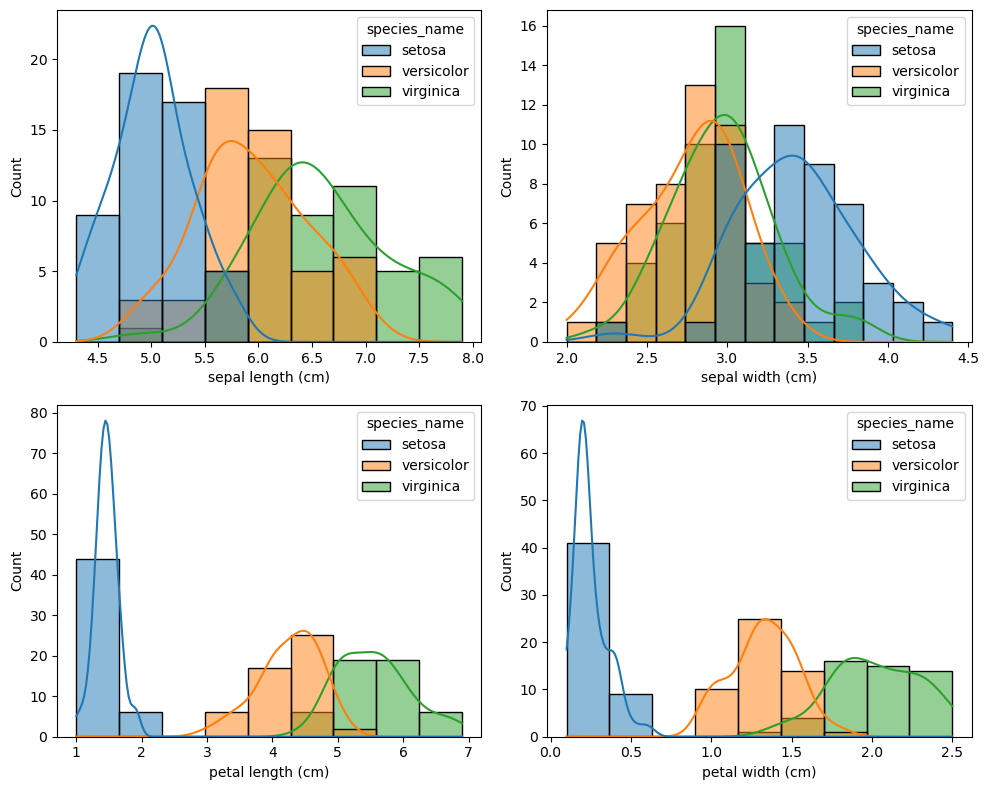

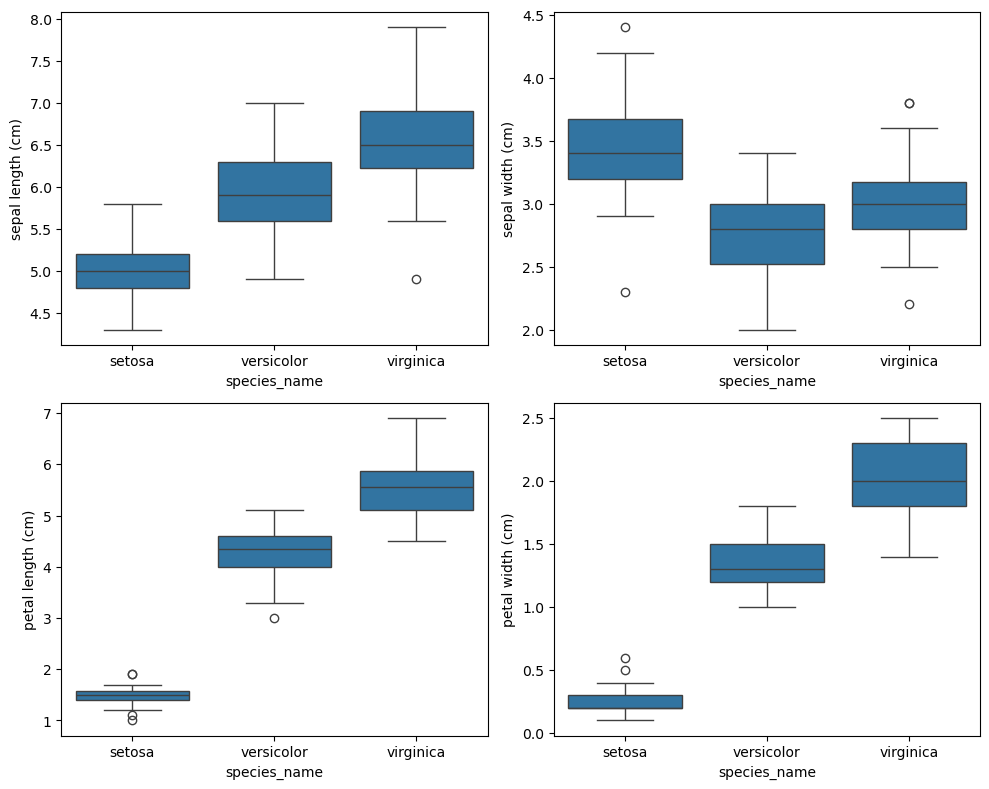

In [6]:
features = iris.feature_names
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feature in zip(axes.ravel(), features):
    sns.histplot(data=df, x=feature, hue="species_name", kde=True, ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feature in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="species_name", y=feature, ax=ax)
plt.tight_layout()
plt.show()

> **Question :** Quels schémas ou anomalies remarquez-vous dans la distribution des caractéristiques ? Certaines caractéristiques semblent-elles mieux différencier les classes ?


---
**Réponse :** Les pétales (longueur et largeur) séparent nettement les classes : setosa a de tout petits pétales, bien isolés des deux autres. Les sépales se recouvrent beaucoup entre versicolor et virginica et différencient mal les classes. Les caractéristiques de pétale sont les plus discriminantes.


6. **Examiner les relations entre les caractéristiques**  
   Utilisez des diagrammes de dispersion (scatter plots) avec `sns.pairplot()` pour visualiser les relations entre les caractéristiques et colorer les points selon la classe.

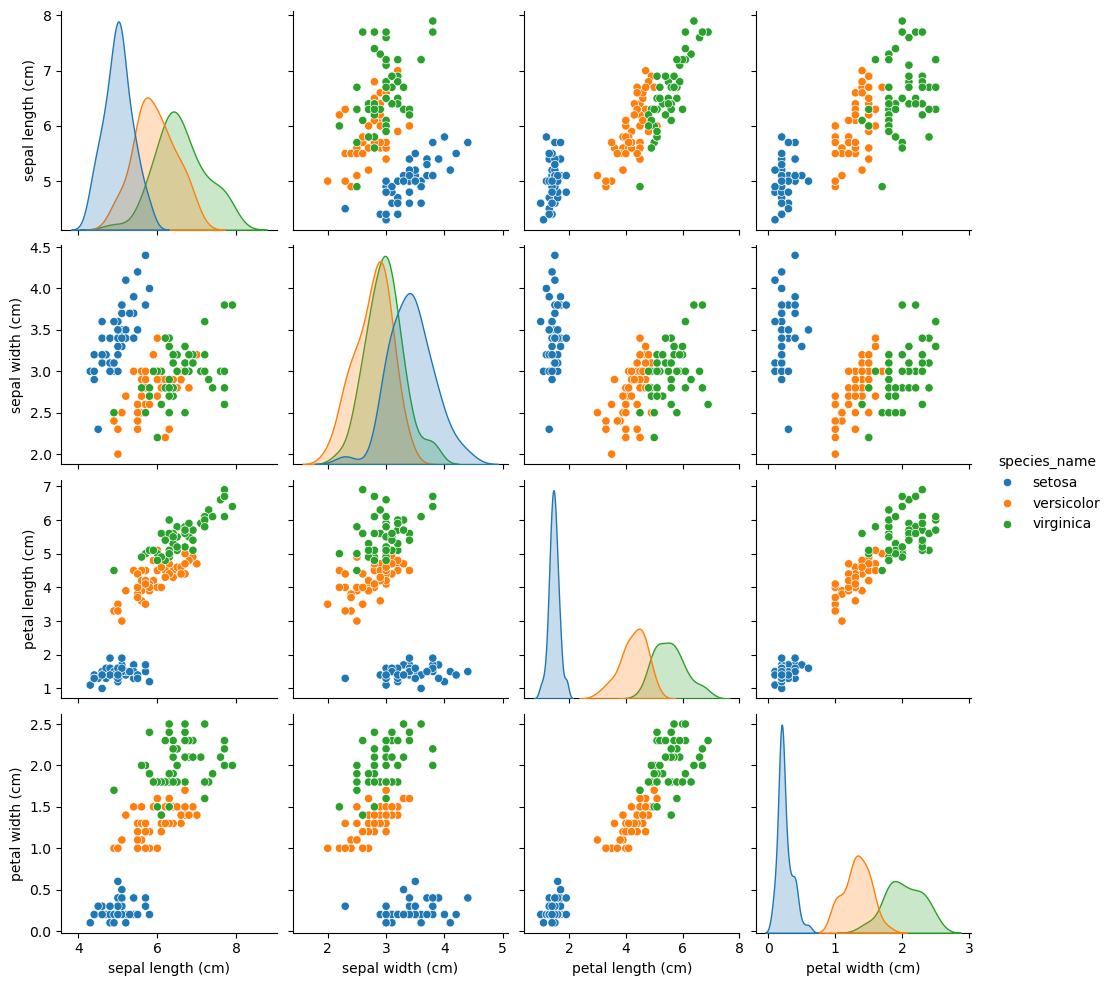

In [7]:
sns.pairplot(df, vars=iris.feature_names, hue="species_name")
plt.show()

> **Question :** Certaines paires de caractéristiques semblent-elles montrer une séparation claire entre les classes ? Si oui, lesquelles ?


---
**Réponse :** Oui : les paires impliquant les pétales (par ex. `petal length` × `petal width`) montrent une séparation claire, surtout pour setosa qui forme un groupe isolé. versicolor et virginica restent un peu chevauchants mais mieux séparés par les pétales que par les sépales.


---

## Étape 3 : Prétraitement des Données

Le prétraitement est une étape cruciale pour préparer les données avant d'entraîner le modèle. Certaines étapes doivent être appliquées uniquement après la séparation des données en ensembles d'entraînement et de test pour éviter le **data leakage** (fuite de données).

> Le **data leakage** survient lorsque des informations du jeu de test influencent le jeu d'entraînement, ce qui fausse les résultats en donnant au modèle un "aperçu" des données de test pendant son entraînement. Cela peut conduire à des performances trompeuses qui ne se généralisent pas bien aux nouvelles données.

1. **Vérifier les doublons**  
   Utilisez la méthode `.duplicated()` pour détecter les lignes en double et `.drop_duplicates()` pour les supprimer si nécessaire.

In [8]:
n_duplicates = df.duplicated().sum()
print(f"Nombre de doublons : {n_duplicates}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Nombre de lignes après suppression des doublons : {len(df)}")

Nombre de doublons : 1
Nombre de lignes après suppression des doublons : 149


 > **Question :** Avez-vous trouvé des doublons dans le dataset ? Si oui, combien ? Pensez-vous que les garder ou les supprimer influencerait l’analyse ?


---
**Réponse :** Oui, 1 doublon a été trouvé et supprimé (149 lignes restantes sur 150). Une seule ligne dupliquée sur 150 a un impact négligeable sur l'analyse.


2. **Encodage des labels**  
   Vérifiez que la colonne des classes (`species`) est sous forme numérique. Si elle est en format texte, utilisez `pd.Categorical` ou `LabelEncoder` de `sklearn` pour encoder les classes en valeurs numériques.


In [9]:
# La colonne "species" contient déjà les classes encodées numériquement (0, 1, 2)
# par sklearn. La colonne "species_name" garde la version texte pour les graphes.
print(df["species"].dtype)
df["species"].unique()

int64


array([0, 1, 2])

 > **Question :** Quelle méthode utiliseriez-vous pour encoder les classes de manière à ce que le modèle puisse les interpréter ? L’encodage est-il déjà effectué ou est-il nécessaire de l’ajouter ?


---
**Réponse :** L'encodage est déjà fait : `load_iris()` fournit `species` sous forme numérique (0, 1, 2), type `int`. Si les classes avaient été en texte, `LabelEncoder` (ou `pd.Categorical`) aurait permis de les convertir en nombres.


3. **Standardisation ou Normalisation (à faire après la séparation train/test, si necessaire)**  
   La standardisation ou normalisation des caractéristiques est recommandée pour certains modèles (comme les modèles sensibles à la distance). Utilisez `StandardScaler` de `sklearn.preprocessing` après la séparation des données.

> **Question :** Pourquoi est-il important de standardiser les caractéristiques après la séparation en train et test ? Que pourrait-il se passer si vous appliquez cette transformation avant la séparation ?


---
**Réponse :** On standardise après le split pour éviter le data leakage : le `StandardScaler` est ajusté (`fit`) uniquement sur `X_train`, puis appliqué (`transform`) au test. Si on standardisait avant, la moyenne et l'écart-type seraient calculés en incluant les données de test, et le modèle « verrait » indirectement le test, ce qui rendrait les scores trop optimistes.


4. **Vérification finale du DataFrame**  
   Assurez-vous que toutes les données sont prêtes pour la modélisation. Vérifiez que les colonnes sont encodées correctement, que le DataFrame ne contient plus de valeurs manquantes ou d’incohérences.

In [10]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nDoublons restants :", df.duplicated().sum())
df.info()

Valeurs manquantes par colonne :
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Doublons restants : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  149 non-null    float64
 1   sepal width (cm)   149 non-null    float64
 2   petal length (cm)  149 non-null    float64
 3   petal width (cm)   149 non-null    float64
 4   species            149 non-null    int64  
 5   species_name       149 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.1+ KB


> **Question :** Le DataFrame semble-t-il maintenant prêt pour la modélisation ? Quelles autres transformations envisageriez-vous ?


---
**Réponse :** Oui : plus aucune valeur manquante, plus de doublon, cible déjà encodée en numérique. La transformation restante est la standardisation, faite juste après le `train_test_split`.


---
## Étape 4 : Diviser les données en ensembles d’entraînement et de test

### 1. Séparation de Features et de Target

1. **Sélectionner les caractéristiques (features)**  
   Dans le dataset Iris, les caractéristiques sont les colonnes numériques représentant les mesures de la fleur (longueur et largeur des sépales et pétales). Assignez ces colonnes à une variable, par exemple `X`.

2. **Définir la cible (target)**  
   La cible, ou `target`, est la variable que vous voulez prédire. Dans ce cas, il s'agit de la colonne `species`, qui contient les classes des fleurs. Assignez cette colonne à une variable, par exemple `y`.


In [11]:
X = df[iris.feature_names]
y = df["species"]

Une fois les caractéristiques (`X`) et la cible (`y`) définies, il est essentiel de diviser les données en deux ensembles distincts pour évaluer la capacité du modèle à généraliser sur de nouvelles données. Cette division nous aide à obtenir une estimation réaliste des performances en conditions réelles, sans "voir" les données de test lors de l'entraînement.

Pour cela, nous utilisons la fonction `train_test_split` de `sklearn.model_selection`, qui renvoie quatre objets distincts : les caractéristiques et les cibles pour les ensembles d’entraînement et de test.


### 2. Division des données avec la fonction `train_test_split`

### `train_test_split`

Voici comment utiliser `train_test_split` et ce que chaque variable représente :

```python
# Diviser les données en ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
```

- **Ce que retourne `train_test_split`** :
  - **`X_train`** : Caractéristiques pour l’entraînement
  - **`X_test`** : Caractéristiques pour le test
  - **`y_train`** : Cible pour l’entraînement
  - **`y_test`** : Cible pour le test

Ces quatre objets forment les ensembles que vous utiliserez pour construire et évaluer le modèle. `X_train` et `y_train` seront utilisés pour l’entraînement, tandis que `X_test` et `y_test` serviront à évaluer ses performances sur des données inédites.


#### Explication des paramètres

- **Pourquoi diviser ?**  
  La division des données est essentielle pour tester la capacité du modèle à généraliser, c'est-à-dire à bien fonctionner sur des données qu’il n’a jamais vues pendant l’entraînement. En général, on utilise 80 % des données pour l’entraînement et 20 % pour le test.

- **Paramètre `test_size=0.2`**  
  Ce paramètre définit la proportion des données à utiliser pour le test. Avec `test_size=0.2`, 20 % des données sont affectées à l’ensemble de test et 80 % à l’ensemble d’entraînement. Vous pouvez ajuster cette valeur (par exemple, `test_size=0.3` pour 30 % des données en test) en fonction des besoins de votre projet.

- **Paramètre `random_state=42`**  
  `random_state` est un entier qui rend la division reproductible. Fixer `random_state=42` garantit que la division reste identique à chaque exécution, ce qui est crucial pour obtenir des résultats cohérents.  
  > **Note :** Changer la valeur de `random_state` modifie l’ordre des données dans chaque division, mais les proportions entre `train` et `test` restent identiques.

- **Paramètre `shuffle=True`**  
  `shuffle` indique si les données doivent être mélangées avant la division. En général, il est préférable de mélanger les données pour s’assurer qu’elles sont bien distribuées entre les ensembles d’entraînement et de test, en particulier si les données sont ordonnées. Par défaut, `shuffle` est défini sur `True`.  
  > **Note :** Dans certains cas (comme les séries temporelles), il est recommandé de ne pas mélanger les données pour conserver l’ordre chronologique.
  

Maintenant, utilisez la cellule suivante pour appliquer `train_test_split` et observer la structure de vos données d’entraînement et de test :

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("y_train :", y_train.shape, "| y_test :", y_test.shape)

X_train : (119, 4) | X_test : (30, 4)
y_train : (119,) | y_test : (30,)


- **Vérification des dimensions des ensembles d'entraînement et de test avec `shape` :**
   > **Question :** En utilisant la méthode `.shape`, les dimensions de `X_train` et `y_train` représentent-elles environ 80 % des données initiales ? Et celles de `X_test` et `y_test`, environ 20 % ?
   
   > **Question :** Pourquoi est-il important de maintenir une proportion équilibrée entre les ensembles d’entraînement et de test ?

- **Impact de `random_state` sur la reproductibilité :**
   > **Question :** Que se passe-t-il lorsque le paramètre `random_state` n’est pas fixé ? Lancez `train_test_split` sans spécifier `random_state=42` et comparez les résultats.

   > **Question :** Pourquoi est-il avantageux d’obtenir la même division des données à chaque exécution du code ?

- **Effet de `shuffle` sur la distribution des données :**
   > **Question :** Si `shuffle` est défini sur `False` dans un dataset organisé par ordre, comment cela pourrait-il influencer l’entraînement et les performances du modèle ?

   > **Question :** Dans quels types de problèmes serait-il pertinent de ne pas mélanger les données avant de les diviser en ensembles d’entraînement et de test ?


---
**Réponse :**
- Proportions : `X_train` = 119 lignes, `X_test` = 30 lignes, soit 119/149 ≈ 80 % et 30/149 ≈ 20 %. `y_train`/`y_test` suivent les mêmes tailles.
- Une proportion équilibrée laisse assez de données pour apprendre (train) et assez pour évaluer de façon fiable (test). Avec `stratify=y`, les 3 classes gardent leurs proportions dans les deux ensembles.
- Sans `random_state`, la division change à chaque exécution : ensembles différents et scores qui varient d'un run à l'autre.
- Fixer `random_state` rend le résultat reproductible : mêmes ensembles à chaque exécution, ce qui permet de comparer les modèles à conditions égales et de retrouver les mêmes résultats.
- `shuffle=False` sur des données triées par classe mettrait certaines classes uniquement dans le train et d'autres uniquement dans le test, ce qui biaiserait l'apprentissage.
- Ne pas mélanger a du sens pour les séries temporelles : on entraîne sur le passé et on teste sur le futur ; mélanger ferait fuiter des informations du futur dans le passé.


---
## Étape 5 : Entraînement des Modèles de Classification

L’entraînement d’un modèle consiste à utiliser les données d’entraînement pour permettre au modèle d’apprendre les relations entre les caractéristiques (`X_train`) et les labels de classe (`y_train`). Ce processus est la base du Machine Learning supervisé, où le modèle cherche à minimiser les erreurs dans ses prédictions en ajustant ses paramètres internes.

Chaque modèle de Machine Learning a des spécificités, des avantages et des limitations en fonction des types de données, des distributions, et des tâches (précision, rapidité, interprétabilité, etc.). Dans cette section, nous allons explorer plusieurs modèles courants en classification, en présentant pour chacun :
- Le principe de fonctionnement,
- Les types de données pour lesquels il est adapté,
- Ses sensibilités aux caractéristiques des données (par exemple, présence d’outliers, nécessité de normalisation),
- Et les contextes où il est le plus performant.


### Syntaxe Générale pour Instancier et Entraîner un Modèle

Pour chaque modèle, l’entraînement suit cette structure de base en Python :

```python
from sklearn.model import ModelClass
# Instancier et entraîner le modèle
model = ModelClass()  # Instancie le modèle avec les paramètres par défaut
model.fit(X_train, y_train)  # Entraîne le modèle sur les données d'entraînement
```
- **Explication :**
    - **`ModelClass()`** : Cette instruction crée une instance du modèle que l’on souhaite utiliser. Par exemple, pour un modèle de K-Nearest Neighbors (KNN), ce sera `KNeighborsClassifier()`. En appelant la classe avec des paramètres par défaut, le modèle utilise des valeurs par défaut pour les hyperparamètres, mais il est possible de les spécifier pour adapter le modèle aux besoins spécifiques du projet (par exemple, `n_neighbors=5` pour KNN).

    - **`.fit(X_train, y_train)`** : La méthode `.fit()` entraîne le modèle en ajustant ses paramètres internes pour minimiser les erreurs entre les prédictions et les valeurs réelles des classes dans `y_train`.  
       - **`X_train`** : Ce sont les caractéristiques (features) des données d’entraînement que le modèle utilise pour trouver des motifs. Ce tableau contient uniquement les variables explicatives, sans la cible.
       - **`y_train`** : Ce vecteur contient les labels de classe pour chaque observation de `X_train`. Le modèle apprend à associer les caractéristiques de chaque observation à sa classe réelle.

Chaque modèle, une fois entraîné avec `.fit()`, pourra ensuite générer des prédictions sur de nouvelles données en utilisant la méthode `.predict()`.

### Modèle 1 : K-Nearest Neighbors (KNN)

- **Principe du modèle :**  
  KNN classe une observation en fonction des classes des `k` voisins les plus proches. Il calcule la distance entre l'observation à prédire et celles d’entraînement, puis assigne la classe majoritaire parmi les voisins les plus proches.

- **Utilité :**  
  Utile pour des problèmes où la similarité entre les points est cruciale. Idéal pour des jeux de données de petite à moyenne taille.

- **Forces :**  
  - Facile à comprendre et à implémenter.
  - Performant sur des données bien séparées ou peu nombreuses.


- **Limitations :**  
  - Sensible à la dimension des données (devient coûteux en calculs lorsque le nombre de caractéristiques est élevé).
  - Nécessite de stocker toutes les données d’entraînement, ce qui peut être lourd en mémoire.


- **Pré-requis :**  
  **Normalisation** des données souvent nécessaire, car KNN est sensible aux échelles des caractéristiques.


- **Sensibilité aux valeurs aberrantes :**  
  KNN est sensible aux valeurs aberrantes, qui peuvent influencer la classification via les calculs de distance.


- **Paramètres clés :**  
  - `n_neighbors` : Nombre de voisins à prendre en compte.
  - `weights` : Pondération des voisins (uniforme ou selon la distance).
  - `metric` : Type de distance (euclidienne par défaut).


- **Classe d'importation :**  
  `from sklearn.neighbors import KNeighborsClassifier`


- **Documentation officielle :**  
  [Documentation KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)


In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### Modèle 2 : Régression Logistique

- **Principe du modèle :**  
  La régression logistique est un modèle linéaire utilisant une fonction sigmoïde pour estimer les probabilités d’appartenance à une classe. Efficace pour les classifications binaires, et extensible aux classifications multiclasse.


- **Utilité :**  
  Particulièrement utile pour des problèmes de classification binaire et multiclasse lorsque les classes sont bien séparées par une frontière linéaire.


- **Forces :**  
  - Facile à interpréter et rapide à entraîner.
  - Performant pour des relations linéaires entre caractéristiques et labels.

- **Limitations :**  
  - Moins performant pour les données non linéaires.
  - Sensible aux multicolinéarités entre caractéristiques, ce qui peut affecter les coefficients du modèle.


- **Pré-requis :**  
  La **standardisation** des données est recommandée pour les modèles linéaires.


- **Sensibilité aux valeurs aberrantes :**  
  Sensible aux outliers, qui peuvent influencer la frontière de décision.


- **Paramètres clés :**  
  - `penalty` : Type de régularisation (par exemple, L1 pour la régularisation de Lasso et L2 pour la régularisation de Ridge).
  - `C` : Inverse de la force de régularisation ; plus `C` est faible, plus la régularisation est forte.
  - `solver` : Algorithme d’optimisation (comme ‘liblinear’ ou ‘saga’).


- **Classe d'importation :**  
  `from sklearn.linear_model import LogisticRegression`


- **Documentation officielle :**  
  [Documentation LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [14]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Modèle 3 : Support Vector Machine (SVM)

- **Principe du modèle :**  
  SVM maximise la marge entre les différentes classes en plaçant un hyperplan de séparation. Les points les plus proches de cet hyperplan (vecteurs de support) influencent la position de cet hyperplan.

- **Utilité :**  
  Performant pour la classification binaire dans des espaces de haute dimension, surtout lorsque les classes sont bien séparables.

- **Forces :**  
  - Performant pour les données de haute dimension.
  - Peut séparer efficacement les données bien séparables avec des marges maximales.


- **Limitations :**  
  - Coût de calcul élevé pour les jeux de données de grande taille.
  - Nécessite une sélection judicieuse des hyperparamètres (ex. : `C` et `gamma`).


- **Pré-requis :**  
  **Standardisation** des données recommandée pour les modèles basés sur les distances.


- **Sensibilité aux valeurs aberrantes :**  
  Sensible aux outliers, qui peuvent influencer la marge et donc l’hyperplan de séparation.


- **Paramètres clés :**  
  - `C` : Paramètre de régularisation.
  - `kernel` : Type de noyau (linéaire, polynomial, radial, etc.).
  - `gamma` : Influence des points dans la marge pour les noyaux non linéaires (comme le noyau RBF).


- **Classe d'importation :**  
  `from sklearn.svm import SVC`


- **Documentation officielle :**  
  [Documentation SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)


In [15]:
from sklearn.svm import SVC

svm = SVC(kernel="linear", random_state=42)
svm.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


### Modèle 4 : Arbre de Décision (Decision Tree)

- **Principe du modèle :**  
  L'arbre de décision divise les données en sous-groupes basés sur des caractéristiques, formant une structure arborescente. Chaque nœud représente une décision, et chaque branche aboutit à une feuille, ou prédiction.
  
- **Utilité :**  
  Utile pour des données complexes et non linéaires. Offre une interprétabilité facile et convient aux applications où les relations non linéaires sont importantes.


- **Forces :**  
  - Interprétable et facile à visualiser.
  - Efficace pour des relations non linéaires et des ensembles de données mixtes (numériques et catégoriels).

- **Limitations :**  
  - Peut être sujet au surapprentissage (overfitting), surtout si l’arbre est profond.
  - Moins performant sur les jeux de données très grands ou avec des classes imbriquées.


- **Pré-requis :**  
  Aucun prétraitement nécessaire (ni normalisation, ni standardisation).

- **Sensibilité aux valeurs aberrantes :**  
  Moins sensible aux valeurs aberrantes, bien que les arbres profonds puissent être influencés.


- **Paramètres clés :**  
  - `max_depth` : Profondeur maximale de l’arbre, pour éviter le surapprentissage.
  - `min_samples_split` : Nombre minimum d’échantillons requis pour diviser un nœud.
  - `criterion` : Mesure de l'impureté (par exemple, `gini` ou `entropy`).


- **Classe d'importation :**  
  `from sklearn.tree import DecisionTreeClassifier`


- **Documentation officielle :**  
  [Documentation DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

#### Exemple d'Arbre de Décision Simplifié

Cet exemple illustre comment un arbre de décision pourrait être utilisé pour prédire si un client acceptera une offre de crédit en fonction de deux caractéristiques : **Revenu** et **Historique de crédit**.

| **Revenu** | **Historique de crédit** | **Accepte offre** |
|------------|--------------------------|--------------------|
| Élevé      | Bon                      | Oui               |
| Faible     | Mauvais                  | Non               |
| Moyen      | Bon                      | Oui               |
| Faible     | Bon                      | Non               |
| Élevé      | Mauvais                  | Oui               |

L'arbre de décision suivant peut représenter cette analyse :

```
               [Revenu?]
                /      \
             Élevé     Faible
            /            \
        [Crédit?]      Non (Feuille)
           /    \
         Bon     Mauvais
        /         \
       Oui       Non (Feuille)
```


#### Explication

1. **Racine de l'arbre** : La première question posée est sur le **revenu** du client. Selon la réponse, l'arbre se divise en deux branches :
   - **Élevé** : Les clients avec un revenu élevé continuent vers la question suivante sur leur historique de crédit.
   - **Faible** : Les clients avec un revenu faible mènent directement à une prédiction "Non" pour l'offre de crédit.


2. **Branches et feuilles** : 
   - Si le revenu est **élevé** et que l’**historique de crédit** est **bon**, l'arbre prédit "Oui".
   - Si le revenu est **élevé** mais l’**historique de crédit** est **mauvais**, l'arbre prédit "Non".


3. **Feuilles** : Les feuilles (Noeuds terminaux) représentent les décisions finales du modèle. Dans cet exemple, la feuille "Oui" signifie que le client acceptera l'offre, tandis que la feuille "Non" signifie qu’il ne l’acceptera pas.


In [16]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Modèle 5 : Forêt d'Arbres Décisionnels (Random Forest)

- **Principe du modèle :**  
  Random Forest combine plusieurs arbres de décision entraînés sur des sous-échantillons des données et utilise une moyenne des prédictions pour améliorer la précision et réduire le surapprentissage.

- **Utilité :**  
  Performant pour des données non linéaires et large échelle. Moins sensible au surapprentissage par rapport aux arbres de décision seuls.


- **Forces :**  
  - Moins sensible au surapprentissage grâce à la moyenne des prédictions de plusieurs arbres.
  - Capable de gérer des caractéristiques de type mixte et des données avec des relations complexes.


- **Limitations :**  
  - Moins interprétable qu’un arbre de décision unique.
  - Peut être coûteux en mémoire et en calcul pour des grands jeux de données.


- **Pré-requis :**  
  Aucun prétraitement spécifique requis (ni normalisation, ni standardisation).


- **Sensibilité aux valeurs aberrantes :**  
  Moins sensible aux valeurs aberrantes, car les prédictions sont basées sur l'agrégation de nombreux arbres.


- **Paramètres clés :**  
  - `n_estimators` : Nombre d’arbres dans la forêt.
  - `max_depth` : Profondeur maximale de chaque arbre.
  - `min_samples_split` : Nombre minimum d’échantillons requis pour diviser un nœud.


- **Classe d'importation :**  
  `from sklearn.ensemble import RandomForestClassifier`


- **Documentation officielle :**  
  [Documentation RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

---
## Étape 6 : Calcul des Prédictions pour Chaque Modèle

Après l'entraînement, nous utilisons chaque modèle pour prédire les classes sur les données de test (`X_test`). Cela nous permet de comparer les prédictions (`y_pred`) aux vraies valeurs (`y_test`) et de vérifier la capacité du modèle à généraliser.

#### Syntaxe Générale

```python
# 4. Prédire les résultats
y_pred = model.predict(X_test)
```

- **Explication** :
   - `.predict(X_test)` : Utilise le modèle entraîné pour prédire les classes du jeu de test. `X_test` contient uniquement les caractéristiques (features) des données de test.
   - `y_pred` : Vecteur contenant les prédictions de chaque observation dans `X_test`.

#### Prédictions pour chaque modèle

Utilisez la cellule suivante pour insérer le code de prédiction pour chaque modèle :

In [18]:
y_pred_knn = knn.predict(X_test_scaled)
y_pred_log_reg = log_reg.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)
y_pred_tree = tree.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)

predictions = {
    "KNN": y_pred_knn,
    "Régression Logistique": y_pred_log_reg,
    "SVM": y_pred_svm,
    "Arbre de Décision": y_pred_tree,
    "Random Forest": y_pred_rf,
}

#### Questions

1. **Précision des Prédictions :**
   > **Question** : Quelle proportion des prédictions de `y_pred` correspond-elle aux vraies classes de `y_test` ?
   
   > **Question** : Les erreurs de prédiction sont-elles concentrées sur une classe spécifique ? Pourquoi cela pourrait-il être le cas ?

2. **Analyse des Prédictions Incorrectes :**
   > **Question** : Examinez quelques exemples de prédictions incorrectes. Identifiez-vous un schéma ou des caractéristiques communes parmi ces erreurs ?

3. **Impact des Caractéristiques sur les Prédictions (pour les modèles linéaires) :**
   > **Question** : Dans les modèles linéaires, certaines caractéristiques influencent-elles les prédictions plus que d’autres ? Comment les coefficients interprétables des modèles linéaires valident-ils ou remettent-ils en question vos intuitions ?


---
**Réponse :**
- Précision des prédictions : sur les 30 fleurs de test, le SVM se trompe 1 fois (29/30 = 96,7 %) ; les 4 autres modèles se trompent 2 fois (28/30 = 93,3 %).
- Concentration des erreurs : les erreurs touchent la frontière versicolor ↔ virginica, ces deux classes ayant des mesures qui se chevauchent. setosa n'est jamais confondue.
- Prédictions incorrectes : les fleurs mal classées sont des cas intermédiaires proches de la frontière versicolor / virginica, avec des mesures de pétales à la limite entre les deux groupes.
- Influence des caractéristiques (modèles linéaires) : les pétales ont des coefficients bien plus grands (en valeur absolue) que les sépales ; ils pèsent le plus dans la décision, ce qui rejoint l'observation de l'EDA.


---
## Étape 7 : Interprétation des Modèles

L’interprétation des modèles consiste à comprendre comment chaque caractéristique influence les prédictions, en particulier en analysant les coefficients et l'importance des caractéristiques dans les modèles interprétables. Cela permet d’identifier les caractéristiques les plus influentes et de comprendre la logique des prédictions du modèle.

### Syntaxe Générale pour Récupérer et Visualiser les Coefficients / Importance des Caractéristiques

Pour les modèles **interprétables**, il est possible de récupérer et de visualiser l’influence des caractéristiques :

- Les **coefficients** et l'**intercept** dans les modèles linéaires (régression logistique, SVM linéaire).
- L’**importance des caractéristiques** dans les modèles basés sur les arbres (arbre de décision, forêts d'arbres).

Un graphique en barres des coefficients ou des importances peut également aider à mieux comprendre l'impact de chaque caractéristique.


#### 1. Récupérer et Visualiser les Coefficients et l’Intercept pour les Modèles Linéaires

Les modèles linéaires comme la régression logistique et le SVM linéaire attribuent des coefficients à chaque caractéristique. L’interception (`intercept_`) représente le biais du modèle, soit le décalage par rapport à l’origine.

```python
# Récupérer les coefficients et l'intercept pour les modèles linéaires
feature_names = X_train.columns  # Noms des caractéristiques
coefficients = model.coef_[0]    # Coefficients pour un modèle linéaire comme LogisticRegression ou SVC
intercept = model.intercept_[0]  # Interception (biais)

# Visualiser les coefficients
plt.figure(figsize=(10, 6))
plt.barh(feature_names, coefficients)
plt.xlabel("Importance des Coefficients")
plt.title("Importance des Caractéristiques dans un Modèle Linéaire")
plt.show()

# Afficher l'intercept
print("Intercept:", intercept)
```

> **Note** : Les attributs `coef_` et `intercept_` sont applicables pour les modèles linéaires comme `LogisticRegression` et `SVC` (lorsque le noyau est linéaire `kernel='linear'`).
                                                                               
> **Important** : Les coefficients (`coef_`) sont uniquement disponibles pour le **SVM avec noyau linéaire** (`kernel='linear'`). Si un **noyau non linéaire** (comme `rbf`, `poly`, ou `sigmoid`) est utilisé, l’attribut `coef_` ne sera pas accessible. Dans ce cas, le modèle utilise une approche complexe qui rend l’interprétation directe des coefficients impossible. 
                                                                   

#### 2. Récupérer et Visualiser l’Importance des Caractéristiques pour les Modèles Basés sur les Arbres

Les modèles d’arbre de décision et les forêts d'arbres n'ont pas de coefficients ou d'intercept, mais ils attribuent une importance relative à chaque caractéristique. L’importance des caractéristiques est accessible via l'attribut `feature_importances_`.

```python
# Récupérer l'importance des caractéristiques pour les modèles basés sur les arbres
importances = model.feature_importances_  # Importance des caractéristiques pour DecisionTreeClassifier ou RandomForestClassifier
feature_names = X_train.columns

# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Importance des Caractéristiques")
plt.title("Importance des Caractéristiques dans un Modèle Basé sur les Arbres")
plt.show()
```

> **Note** : `feature_importances_` est applicable aux modèles `DecisionTreeClassifier` et `RandomForestClassifier`.


### Explication

1. **`feature_names = X_train.columns`** : Récupère les noms des caractéristiques dans `X_train` pour les afficher sur l’axe des y du graphique.

2. **Récupérer les coefficients et l’intercept (modèles linéaires)** :
   - **`model.coef_[0]`** : Donne les coefficients associés à chaque caractéristique, qui indiquent l’influence de chaque variable dans le modèle.
   - **`model.intercept_[0]`** : Donne l’intercept (biais), représentant le décalage de la fonction de prédiction par rapport à l’origine.

3. **Récupérer l’importance des caractéristiques (modèles basés sur les arbres)** :
   - **`model.feature_importances_`** : Donne une mesure d’importance de chaque caractéristique, indiquant la contribution moyenne d'une caractéristique dans la réduction d’impureté sur l’ensemble des arbres (Random Forest) ou sur les noeuds (Arbre de Décision).

4. **Visualisation avec `plt.barh()`** :
   - **Graphique en barres horizontales (`plt.barh`)** : Trace un graphique avec les noms des caractéristiques sur l’axe y et leurs coefficients ou importances respectives sur l’axe x. 
   - **`plt.xlabel` et `plt.title`** : Ajoutent des labels et un titre pour clarifier la visualisation.

5. **Afficher l’intercept (si applicable)** :
   - **`print("Intercept:", intercept)`** : Affiche la valeur de l'interception, utile pour interpréter la prédiction de base lorsque toutes les caractéristiques sont à zéro (modèles linéaires seulement).

Ce code permet d'explorer et de visualiser les influences des caractéristiques dans les modèles interprétables, en se basant sur leurs coefficients ou leur importance relative.

### Interprétation des Modèles

L'interprétation des modèles en classification permet de comprendre comment chaque caractéristique influence les prédictions. Pour les modèles linéaires, on peut analyser les **coefficients**, et pour les modèles d’arbre, on utilise l'**importance des caractéristiques**. Cette section se concentre sur l’interprétation des caractéristiques et l’analyse des résultats de prédiction.


#### 1. Régression Logistique

- **Principe** : La régression logistique est un modèle linéaire qui utilise des coefficients pour chaque caractéristique afin de déterminer la probabilité d’appartenance à une classe.

- **Interprétation des Coefficients** :
  - En **classification binaire** (2 classes), chaque coefficient indique l'influence d'une caractéristique sur la probabilité de la classe positive (habituellement codée par `1`).
  - En **classification multiclasses** (plus de 2 classes), le modèle utilise une approche "un contre tous" (one-vs-rest) avec un ensemble de coefficients pour chaque classe. La classe avec la probabilité la plus élevée est alors choisie comme la prédiction.
  > **Note** : Pour obtenir les probabilités, utilisez directement `model.predict_proba()`

- **Instructions** : Visualisez les coefficients pour observer l’influence de chaque caractéristique sur les prédictions. Un coefficient positif augmente la probabilité de la classe correspondante, tandis qu’un coefficient négatif la réduit.


In [19]:
coef_log_reg = pd.DataFrame(
    log_reg.coef_, columns=iris.feature_names, index=iris.target_names
)
coef_log_reg

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-1.046866,1.167085,-1.698177,-1.633075
versicolor,0.562217,-0.467424,-0.294886,-0.812525
virginica,0.484650,-0.699661,1.993064,2.445600


> **Questions** :
  > - Quelles caractéristiques ont les coefficients les plus élevés ? Que suggère cela concernant leur impact sur la prédiction ?
  > - Parmi les caractéristiques ayant des coefficients positifs, lesquelles augmentent le plus la probabilité d’une classe spécifique ?
  > - Y a-t-il des caractéristiques avec des coefficients négatifs importants ? Comment pensez-vous qu'elles influencent la probabilité des classes ?
  > - La classe avec la probabilité la plus élevée est-elle toujours la classe prédite ?


---
**Réponse :**
- Les coefficients les plus forts (en valeur absolue) sont sur `petal length` et `petal width` : ce sont elles qui pèsent le plus.
- Pour virginica, `petal width` (+2,45) et `petal length` (+1,99) sont fortement positifs : de grands pétales augmentent la probabilité d'être virginica.
- Pour setosa, `petal length` (−1,70) et `petal width` (−1,63) sont fortement négatifs : de grands pétales réduisent la probabilité setosa (setosa a de petits pétales).
- La classe prédite est celle dont la probabilité (`predict_proba`) est la plus élevée parmi les 3, elle n'est donc pas fixe.


#### 2. SVM Linéaire (SVC avec `kernel='linear'`)

- **Principe** : Le SVM linéaire est un modèle qui maximise la marge de séparation entre les classes, en utilisant des coefficients pour chaque caractéristique.

- **Interprétation des Coefficients** :
  - En **classification binaire**, chaque coefficient indique l’influence d'une caractéristique pour distinguer les deux classes.
  - En **classification multiclasses** (plus de 2 classes), SVC utilise une approche "un contre un" (one-vs-one) pour entraîner des classificateurs binaires pour chaque paire de classes. La classe ayant le plus de "votes" parmi ces comparaisons est choisie comme la classe prédite.
  
  > **Note** : Utilisez `model.decision_function()` pour obtenir les scores de décision entre classes.

- **Instructions** : Visualisez les coefficients pour chaque classe pour observer comment les caractéristiques influencent les décisions du modèle.


In [20]:
coef_svm = pd.DataFrame(
    svm.coef_, columns=iris.feature_names, index=iris.target_names
)
coef_svm

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-0.171199,0.550192,-0.586951,-0.754903
versicolor,-0.114510,0.315699,-0.476930,-0.442992
virginica,0.498352,0.411640,-2.062657,-2.292028


> **Questions** :
  >- Quelles caractéristiques ont les coefficients les plus élevés pour chaque classe ? Comment influencent-elles la séparation des classes ?
  >- Comment les caractéristiques influentes pour une paire de classes diffèrent-elles d'une autre paire de classes ?
  >- Dans les cas où plusieurs classes sont proches en termes de scores de décision, qu'est-ce que cela suggère sur la difficulté de séparation entre ces classes ?


---
**Réponse :**
- Comme pour la régression logistique, les pétales dominent. Pour la ligne virginica, `petal length` (−2,06) et `petal width` (−2,29) ont les plus gros coefficients ; ce sont elles qui tracent la frontière.
- Les caractéristiques influentes varient selon la classe : les sépales pèsent un peu plus pour setosa, mais les pétales restent décisifs partout.
- Quand les scores de décision (`decision_function`) de deux classes sont proches, cela indique une frontière difficile, typiquement versicolor vs virginica.


#### 3. Arbre de Décision

- **Principe** : L'arbre de décision divise les données en sous-groupes successifs en fonction de conditions sur les caractéristiques. La structure de l’arbre montre les décisions prises pour arriver à une prédiction.

- **Interprétation de l'Importance des Caractéristiques** :
  - Dans un arbre de décision, chaque caractéristique a une **importance** (`feature_importances_`) qui indique combien de fois cette caractéristique a été utilisée pour diviser les données.
  - Une importance élevée signifie que la caractéristique est souvent utilisée pour faire des distinctions entre les classes.
  
    > **Note** : Utilisez `plot_tree()` pour afficher la structure de l’arbre et observer les décisions prises à chaque niveau.
    
- **Instructions** : Visualisez l’arbre pour observer comment chaque caractéristique est utilisée dans les divisions.


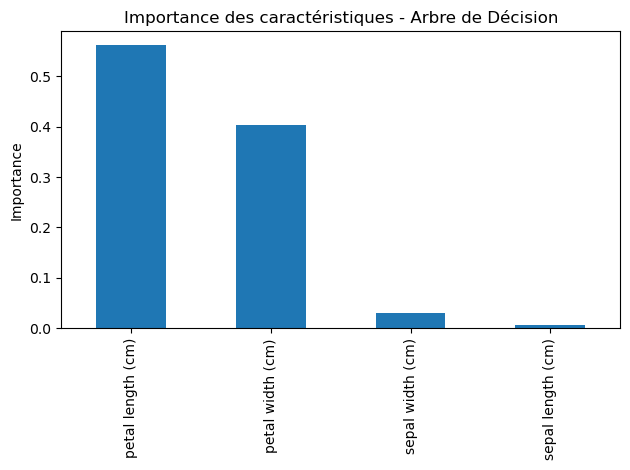

In [21]:
importances_tree = pd.Series(tree.feature_importances_, index=iris.feature_names)
importances_tree.sort_values(ascending=False).plot(kind="bar")
plt.title("Importance des caractéristiques - Arbre de Décision")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

> **Questions** :
  >- Quelles caractéristiques apparaissent aux premiers niveaux de l'arbre ? Pourquoi pensez-vous qu'elles sont importantes pour diviser les données ?
  >- Quelles caractéristiques ont l’importance la plus élevée selon `feature_importances_` ? Ces résultats sont-ils cohérents avec ce que vous attendiez ?
  >- Lors de la visualisation de l’arbre, identifiez les chemins décisionnels pour une classe spécifique. Quelles caractéristiques semblent être déterminantes ?


---
**Réponse :**
- Les caractéristiques les plus importantes sont `petal length` (≈0,56) puis `petal width` (≈0,40). Les sépales sont quasi inutilisés (importance ≈0,03 et 0,006).
- C'est cohérent avec l'EDA et avec les modèles linéaires : les pétales séparent le mieux les classes, donc l'arbre coupe d'abord dessus (proche de la racine).


#### 4. Forêt d'Arbres Décisionnels (Random Forest)

- **Principe** : Random Forest est un ensemble d’arbres de décision, où chaque arbre est entraîné sur un sous-échantillon des données. La prédiction finale est obtenue par vote majoritaire des prédictions de chaque arbre.

- **Interprétation de l'Importance des Caractéristiques** :
  - L'importance des caractéristiques dans Random Forest est la moyenne des importances observées dans chaque arbre de la forêt. Cette moyenne est accessible via `feature_importances_`.
  
  > **Note** : Utilisez `model.estimators_` pour visualiser des arbres individuels si besoin.
  
- **Instructions** : Visualisez l’importance des caractéristiques pour comprendre quelles caractéristiques influencent le plus les décisions globales du modèle.

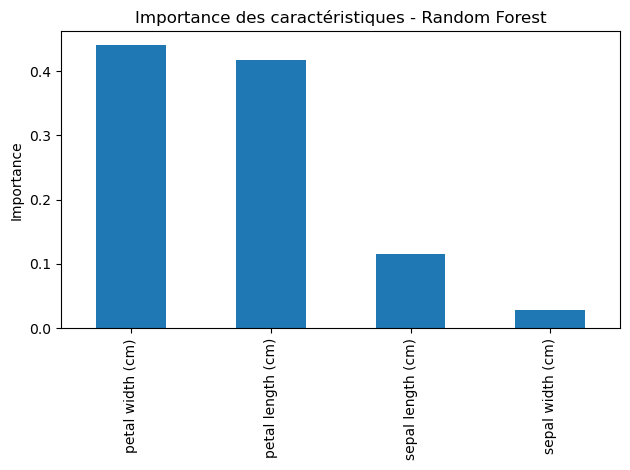

In [22]:
importances_rf = pd.Series(rf.feature_importances_, index=iris.feature_names)
importances_rf.sort_values(ascending=False).plot(kind="bar")
plt.title("Importance des caractéristiques - Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

> **Questions** :
  >- Quelles caractéristiques ont la plus grande importance moyenne ? Pourquoi pensez-vous qu'elles influencent globalement la forêt ?
  >- Les caractéristiques importantes sont-elles cohérentes avec celles observées dans l’arbre de décision unique ? Pourquoi ou pourquoi pas ?
  >- Comment des caractéristiques avec des importances moyennes faibles pourraient-elles encore jouer un rôle dans les prédictions individuelles d’arbres spécifiques ?


---
**Réponse :**
- Les plus importantes sont encore les pétales : `petal width` (≈0,44) et `petal length` (≈0,42) ; les sépales restent faibles.
- Cohérent avec l'arbre unique. Différence : la forêt répartit un peu plus d'importance sur `sepal length` (≈0,12 contre ≈0,006 pour l'arbre seul), car chaque arbre est entraîné sur un sous-échantillon de variables.
- Une caractéristique peu importante en moyenne peut rester décisive dans quelques arbres particuliers pour trancher des cas limites.


#### 5. K-Nearest Neighbors (KNN)

- **Principe** : KNN classe une observation en fonction des classes des `k` voisins les plus proches dans l’espace des caractéristiques. Il ne possède pas de coefficients ou d’importance des caractéristiques.

- **Interprétation** :
  - KNN est influencé par les distances aux voisins. La normalisation des caractéristiques peut avoir un impact important sur les résultats, car les caractéristiques avec des échelles différentes affecteront les distances de manière inégale.

- **Instructions** : Expérimentez avec la normalisation des données et différentes valeurs de `k` pour observer leur impact sur les prédictions.


In [23]:
for k in [1, 3, 5, 7, 9, 15]:
    model_k = KNeighborsClassifier(n_neighbors=k)
    model_k.fit(X_train_scaled, y_train)
    acc_k = model_k.score(X_test_scaled, y_test)
    print(f"k={k:2d} -> accuracy sur le test set = {acc_k:.3f}")

k= 1 -> accuracy sur le test set = 0.967
k= 3 -> accuracy sur le test set = 0.933
k= 5 -> accuracy sur le test set = 0.933
k= 7 -> accuracy sur le test set = 0.967
k= 9 -> accuracy sur le test set = 1.000
k=15 -> accuracy sur le test set = 1.000


> **Questions d’Interprétation** :
  >- Comment la normalisation ou standardisation des caractéristiques affecte-t-elle les voisins les plus proches et les prédictions ?
  >- Comment le choix de `k` influence-t-il les prédictions et la stabilité des résultats ?
  >- Dans quels cas les observations de classes différentes peuvent-elles se retrouver très proches les unes des autres ? Quelles implications cela peut-il avoir sur la précision des prédictions de KNN ?


---
**Réponse :**
- Standardisation : sans elle, une caractéristique à grande échelle domine le calcul de distance et fausse les voisins. Ici toutes les mesures sont en cm mais d'amplitudes différentes, donc la standardisation équilibre leur poids.
- Choix de `k` : petit `k` (k=1) donne un modèle très sensible au bruit (0,967) ; en augmentant `k`, les prédictions se stabilisent (k=9 et k=15 → 1,000 sur ce test de 30 fleurs).
- Classes proches : versicolor et virginica ont des mesures qui se chevauchent, leurs points sont parfois très proches dans l'espace, ce qui provoque les rares erreurs de KNN.


--- 
## Étape 8 : Évaluation des Modèles

Pour évaluer les performances d’un modèle d'apprentissage supervisé, nous avons recours à diverses métriques d’évaluation, qui permettent d’interpréter les résultats en fonction des objectifs spécifiques du projet.


### Syntaxe Générale pour l'Évaluation

Utilisez cette structure pour évaluer les performances de chaque modèle avec les fonctions de `sklearn.metrics` :

```python
# Évaluer le modèle avec des métriques de classification
from sklearn import metrics
score = metrics.some_metric(y_test, y_pred)  # Remplacez some_metric par la métrique souhaitée
```

**Évaluation avec `metrics` de `sklearn`** :
   - Le module `metrics` fournit de nombreuses fonctions pour évaluer les performances d’un modèle. Par exemple, en classification, vous pouvez utiliser `accuracy_score` (exactitude), `precision_score` (précision), `recall_score` (rappel), et `f1_score`. En régression, des métriques comme `mean_squared_error` mesurent l’erreur quadratique moyenne.
   - Le choix des métriques dépend de la tâche (classification ou régression) et des priorités du projet (minimiser les erreurs positives ou négatives, par exemple).

Pour évaluer les performances d’un modèle de classification, la **matrice de confusion** est souvent utilisée comme point de départ. Elle permet de visualiser les prédictions correctes et incorrectes pour chaque classe, et fournit les informations nécessaires pour calculer les principales métriques de performance.

### Matrice de Confusion

La **matrice de confusion** est un tableau qui présente les prédictions correctes et incorrectes par classe. Elle est structurée de façon à montrer les **Vrais Positifs (VP)**, **Faux Négatifs (FN)**, **Faux Positifs (FP)**, et **Vrais Négatifs (VN)**, ce qui facilite le calcul des métriques d’évaluation.

|                    | Prédit : Positif          | Prédit : Négatif           |
|--------------------|---------------------------|-----------------------------|
| **Réel : Positif** | <span style="color:green">Vrais Positifs (VP)</span> | <span style="color:red">Faux Négatifs (FN)</span> |
| **Réel : Négatif** | <span style="color:red">Faux Positifs (FP)</span>    | <span style="color:green">Vrais Négatifs (VN)</span> |

**Interprétation** :
- **Vrais Positifs (VP)** : Observations correctement classées comme positives.
- **Faux Négatifs (FN)** : Observations positives mal classées comme négatives.
- **Faux Positifs (FP)** : Observations négatives mal classées comme positives.
- **Vrais Négatifs (VN)** : Observations correctement classées comme négatives.




Utilisez `confusion_matrix` de `sklearn.metrics` pour visualiser et interpréter les erreurs de classification. La matrice de confusion affiche les prédictions correctes et incorrectes pour chaque classe, ce qui aide à identifier les types d’erreurs du modèle.

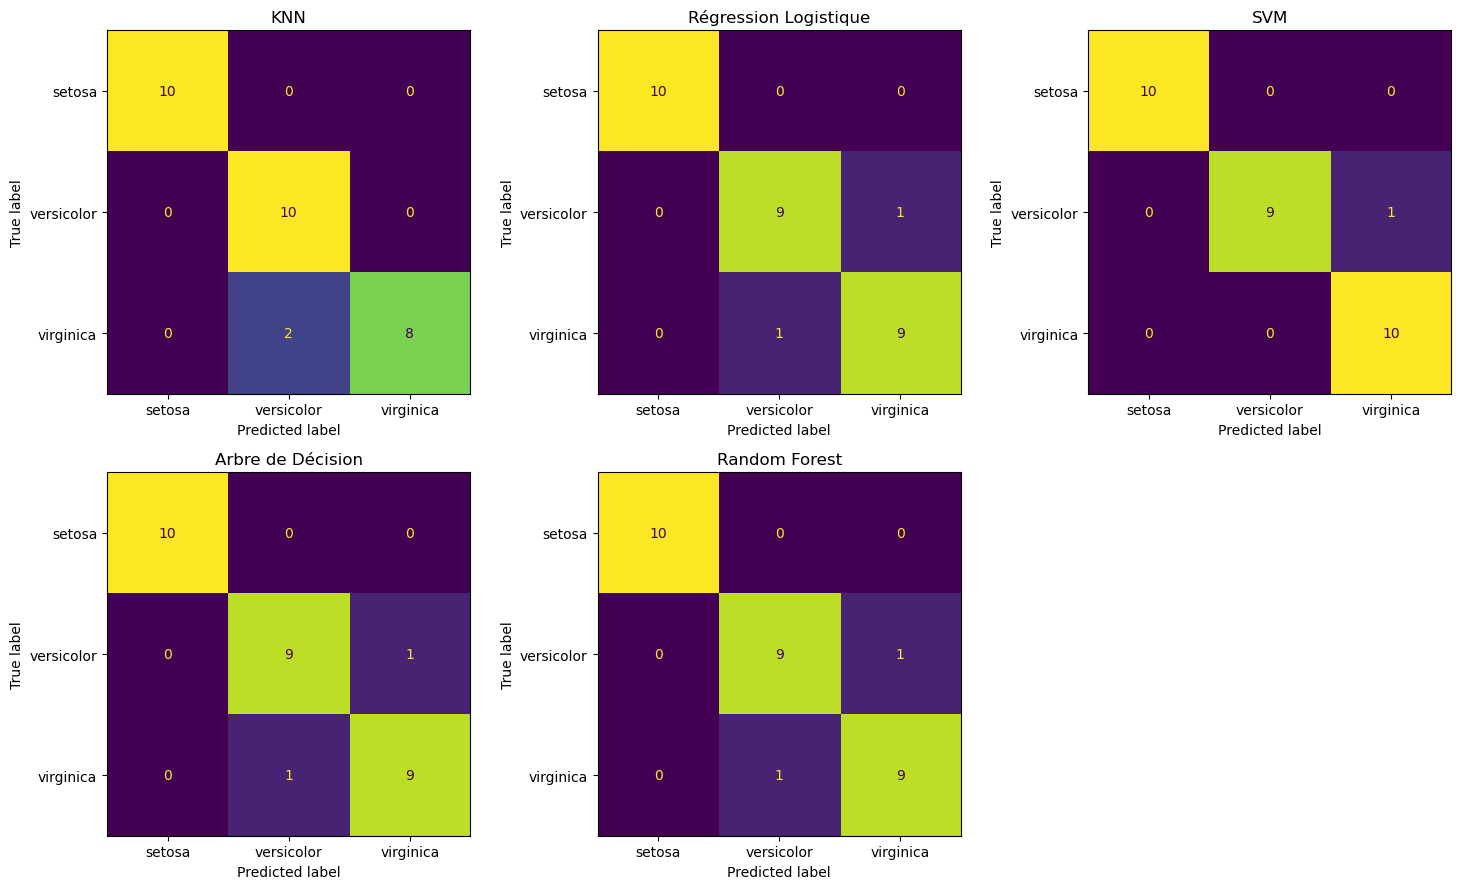

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, y_pred) in zip(axes.ravel(), predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

**Instructions** :
1. Calculez la matrice de confusion pour observer les erreurs de prédiction.
2. Interprétez les valeurs de faux positifs (FP) et de faux négatifs (FN) pour comprendre où le modèle se trompe le plus.

**Questions** :
   - Quels sont les éléments principaux dans la diagonale de la matrice de confusion ? Que représentent-ils ?
   - Quels sont les éléments hors diagonale ? Que peut-on en déduire sur les erreurs du modèle ?
   - Dans quelles classes observe-t-on le plus d’erreurs de prédiction (FP ou FN) ? À quoi cela pourrait-il être dû ?

> **Note** : Pour un problème de classification avec plusieurs classes, comme le jeu de données Iris (3 classes), la matrice de confusion est une matrice carrée de taille \( n \times n \) où \( n \) est le nombre de classes. Chaque case \( (i, j) \) de la matrice représente le nombre d'observations de la classe réelle \( i \) qui ont été prédites comme appartenant à la classe \( j \). Les valeurs sur la diagonale indiquent les prédictions correctes pour chaque classe, tandis que les valeurs hors diagonale montrent les erreurs de classification.

**Exemple dans le cas d'Iris** :
   - Supposons que nous avons les classes **Setosa (0)**, **Versicolor (1)**, et **Virginica (2)**.
   - Un **faux positif (FP)** pour la classe Versicolor se produit lorsqu’une observation Virginica ou Setosa est incorrectement classée comme Versicolor.
   - Un **faux négatif (FN)** pour la classe Virginica se produit lorsqu’une observation Virginica est incorrectement classée comme Setosa ou Versicolor.

Ces erreurs peuvent être dues à une similarité entre certaines caractéristiques des classes Virginica et Versicolor, rendant la séparation entre elles plus difficile pour le modèle.


---
**Réponse :**
- Diagonale : prédictions correctes (classe réelle = classe prédite), une case par classe.
- Hors diagonale : erreurs. La case (ligne i, colonne j) compte les fleurs de classe réelle i prédites en classe j.
- Les erreurs se concentrent entre versicolor et virginica. SVM : 1 versicolor prédite virginica. KNN : 2 virginica prédites versicolor. setosa est toujours correctement classée. Cause : le chevauchement des mesures entre ces deux espèces.


### Métriques d’Évaluation en Classification

Ces métriques sont basées sur la **matrice de confusion** et permettent d'interpréter les résultats en fonction des objectifs du projet.

#### 1. **Accuracy** : Le pourcentage de prédictions correctes parmi toutes les prédictions.
   - **Formule** :$ \text{Accuracy} = \frac{\text{VP + VN}}{\text{Total des Prédictions}} $
   - **Fonction dans `sklearn`** : `metrics.accuracy_score`
   - **Interprétation** : Mesure globale de la performance. Une accuracy élevée signifie que le modèle effectue correctement la majorité des prédictions.
   - **Utilité** : Indicateur simple et efficace lorsque les classes sont **équilibrées**. Cependant, si une classe est dominante (déséquilibre), l’accuracy peut être trompeuse.
   - **Exemple** : Dans la classification d’images de vêtements, si les catégories sont équilibrées (par ex. chaussures vs t-shirts), l’accuracy donne une bonne idée de la performance globale. En revanche, pour des données déséquilibrées, comme la détection de défauts dans une chaîne de production, une accuracy élevée pourrait ne refléter que la dominance de la classe majoritaire.

In [25]:
from sklearn.metrics import accuracy_score

accuracy_scores = {name: accuracy_score(y_test, y_pred) for name, y_pred in predictions.items()}
accuracy_scores

{'KNN': 0.9333333333333333,
 'Régression Logistique': 0.9333333333333333,
 'SVM': 0.9666666666666667,
 'Arbre de Décision': 0.9333333333333333,
 'Random Forest': 0.9333333333333333}

>**Questions** :
   >- L’accuracy est-elle similaire entre les modèles ? Qu’est-ce que cela indique sur la performance globale de chaque modèle ?
   >- Dans un cas de classes équilibrées, pensez-vous que l'accuracy est une mesure fiable pour évaluer la performance ?


---
**Réponse :** Les accuracy sont très proches : SVM 0,967, et KNN / LogReg / Arbre / Random Forest à 0,933. Comme les classes sont équilibrées, l'accuracy est ici une mesure fiable.


#### 2. **Précision (Precision)** : Proportion des prédictions positives qui sont correctes.
   - **Formule** : $ \text{Précision} = \frac{\text{VP}}{\text{VP + FP}} $
   - **Fonction dans `sklearn`** : `metrics.precision_score` avec le paramètre `average='macro'` ou `average='weighted'` pour les cas multiclasses.
   > **Note pour les cas multiclasses** :  
   >- **`average='macro'`** : Calcule la métrique indépendamment pour chaque classe, puis fait la moyenne. Cela donne un poids égal à chaque classe, quelle que soit sa fréquence.
   >- **`average='weighted'`** : Calcule la métrique pour chaque classe puis fait une moyenne pondérée selon la fréquence de chaque classe. Cela prend en compte le déséquilibre des classes pour refléter plus fidèlement la performance globale.
   - **Interprétation** : La précision mesure la fiabilité des prédictions positives du modèle. Une précision élevée indique que le modèle commet peu d’erreurs lorsqu’il prédit une observation positive.
   - **Utilité** : Essentielle lorsque les **faux positifs sont coûteux** ou indésirables. On favorise une haute précision lorsque l’on souhaite éviter de prédire positivement à tort.
   - **Exemple** : En **détection de fraudes**, une fausse alerte (faux positif) est coûteuse car elle pourrait entraîner des enquêtes inutiles. Une haute précision signifie que les transactions signalées sont très probablement frauduleuses.

In [26]:
from sklearn.metrics import precision_score

precision_scores = {
    name: precision_score(y_test, y_pred, average="macro")
    for name, y_pred in predictions.items()
}
precision_scores

{'KNN': 0.9444444444444445,
 'Régression Logistique': 0.9333333333333332,
 'SVM': 0.9696969696969697,
 'Arbre de Décision': 0.9333333333333332,
 'Random Forest': 0.9333333333333332}

>**Questions** :
   >- La précision est-elle équilibrée entre les classes et entre les modèles ?
   >- Pour ce projet, une précision élevée est-elle plus importante qu’un bon rappel ? Pourquoi ?


---
**Réponse :** La précision (macro) est équilibrée et élevée (≈0,93–0,97, SVM en tête). Sur Iris, aucune classe n'est plus coûteuse qu'une autre, donc précision et rappel ont la même importance. La précision primerait seulement si un faux positif coûtait cher.


#### 3. **Rappel (Recall)** : Proportion des instances positives correctement identifiées par le modèle.
   - **Formule** : $ \text{Rappel} = \frac{\text{VP}}{\text{VP + FN}} $
   - **Fonction dans `sklearn`**: `metrics.recall_score`avec le paramètre `average='macro'` ou `average='weighted'` pour les cas multiclasses.
   - **Interprétation** : Le rappel mesure la capacité du modèle à capturer toutes les instances positives. Un rappel élevé indique que le modèle détecte bien les cas positifs.
   - **Utilité** : Crucial quand il est important de **minimiser les faux négatifs**, notamment lorsque chaque cas positif manqué a de graves conséquences.
   - **Exemple** : Dans le **dépistage médical**, comme le dépistage du cancer, un haut rappel est essentiel car chaque faux négatif (cas positif non détecté) pourrait passer inaperçu. Le modèle doit donc être très sensible aux cas positifs pour détecter le plus grand nombre de cas possibles.

In [27]:
from sklearn.metrics import recall_score

recall_scores = {
    name: recall_score(y_test, y_pred, average="macro")
    for name, y_pred in predictions.items()
}
recall_scores

{'KNN': 0.9333333333333332,
 'Régression Logistique': 0.9333333333333332,
 'SVM': 0.9666666666666667,
 'Arbre de Décision': 0.9333333333333332,
 'Random Forest': 0.9333333333333332}

 >**Questions** :
   >- Les valeurs de rappel sont-elles similaires pour chaque classe et chaque modèle ?
   >- Pour ce projet, est-il préférable d’optimiser le rappel ou la précision ? Pourquoi ?


---
**Réponse :** Les valeurs de rappel (macro) sont proches entre modèles (≈0,93, SVM 0,967). Sur Iris, les erreurs sont symétriques et sans enjeu particulier, donc ni rappel ni précision ne prime. Le rappel primerait dans un contexte où rater un cas positif est grave.


#### 4. **F1-Score** : Moyenne harmonique entre la précision et le rappel.
   - **Formule** : $ \text{F1-Score} = 2 \cdot \frac{\text{Précision} \times \text{Rappel}}{\text{Précision + Rappel}} $
   - **Fonction dans `sklearn`** : `metrics.f1_score` avec le paramètre `average='macro'` ou `average='weighted'` pour les cas multiclasses.
   - **Interprétation** : Le F1-score équilibre la précision et le rappel. Un F1-score élevé signifie que le modèle a une bonne performance globale sans sacrifier l’une des deux métriques.
   - **Utilité** : Particulièrement utile lorsque les **classes sont déséquilibrées** ou lorsque l’on veut à la fois limiter les faux positifs et les faux négatifs.
   - **Exemple** : Dans la **détection de spams**, un bon F1-score est souhaitable pour minimiser les emails légitimes classés comme spams (précision) tout en capturant efficacement les spams (rappel), offrant ainsi un équilibre entre précision et rappel.

In [28]:
from sklearn.metrics import f1_score

f1_scores = {
    name: f1_score(y_test, y_pred, average="macro")
    for name, y_pred in predictions.items()
}
f1_scores

{'KNN': 0.9326599326599326,
 'Régression Logistique': 0.9333333333333332,
 'SVM': 0.9665831244778612,
 'Arbre de Décision': 0.9333333333333332,
 'Random Forest': 0.9333333333333332}

>**Questions** :
   >- Le F1-score est-il le même entre les classes et les modèles ?
   >- Le F1-score le plus élevé correspond-il également au meilleur équilibre précision/rappel pour le modèle ?


---
**Réponse :** Le F1-score suit les autres métriques : SVM 0,967, les autres 0,933. Précision et rappel étant quasi identiques ici, le F1 (leur moyenne harmonique) l'est aussi. Le meilleur F1 correspond au SVM, qui a aussi le meilleur équilibre précision/rappel.


#### Instructions pour Regrouper et Comparer les Résultats

1. **Regroupez les résultats** : Compilez les résultats des métriques (accuracy, précision, rappel, F1-score) pour chaque modèle dans un tableau ou une structure, ce qui facilitera la comparaison.
2. **Analysez les performances** : Comparez les modèles en fonction des valeurs de chaque métrique pour déterminer lequel est le plus adapté aux objectifs du projet.

In [29]:
results = pd.DataFrame({
    "Accuracy": accuracy_scores,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1-score": f1_scores,
})
results.sort_values("F1-score", ascending=False)

,Accuracy,Precision,Recall,F1-score
SVM,0.966667,0.969697,0.966667,0.966583
Régression Logistique,0.933333,0.933333,0.933333,0.933333
Arbre de Décision,0.933333,0.933333,0.933333,0.933333
Random Forest,0.933333,0.933333,0.933333,0.933333
KNN,0.933333,0.944444,0.933333,0.932660


## Interprétation des Résultats

Après avoir calculé et regroupé les métriques pour chaque modèle, il est essentiel d’analyser ces résultats afin d’identifier le modèle le mieux adapté aux objectifs du projet. Cette section vous guidera dans l’interprétation des métriques et des différences entre les modèles, tout en prenant en compte les compromis possibles.

#### 1. Comparaison des Performances des Modèles

   - **Analyse des Métriques** : Comparez chaque modèle sur l’ensemble des métriques (accuracy, précision, rappel, F1-score) pour identifier les forces et faiblesses spécifiques.
      - Un modèle avec une **accuracy** élevée peut indiquer une bonne performance générale, mais cette métrique peut être trompeuse en cas de classes déséquilibrées.
      - La **précision** révèle la fiabilité des prédictions positives, ce qui est essentiel lorsque les faux positifs sont coûteux.
      - Le **rappel** montre la capacité du modèle à capturer tous les cas positifs, important pour minimiser les faux négatifs dans des applications sensibles comme le diagnostic médical.
      - Le **F1-score** offre un bon équilibre entre précision et rappel, particulièrement utile lorsque les faux positifs et les faux négatifs ont un coût similaire.

   **Questions** :
   - Quels modèles montrent des performances similaires ou des différences marquées sur certaines métriques ?
   - Quel modèle semble le mieux adapté aux objectifs du projet et à ses besoins (ex. haute précision, rappel) ?

#### 2. Analyse des Forces et Faiblesses de Chaque Modèle

   - **Forces des Modèles** : Identifiez les points forts en fonction des métriques clés. Par exemple :
      - Les modèles avec une précision élevée sont fiables pour les prédictions positives, réduisant les erreurs de faux positifs.
      - Les modèles ayant un bon rappel détectent mieux les cas positifs, ce qui peut être crucial dans des domaines comme la santé.

   - **Faiblesses des Modèles** : Notez les faiblesses éventuelles, comme un faible rappel ou une précision réduite, et réfléchissez à leur impact dans le contexte du projet.

   **Questions** :
   - Pour chaque modèle, quelles faiblesses peuvent être acceptées et quelles devraient être minimisées en fonction des objectifs du projet ?
   - En quoi les forces et les faiblesses de chaque modèle influencent-elles votre choix final ?

#### 3. Impact des Erreurs : Faux Positifs et Faux Négatifs

   - **Faux Positifs (FP)** : Les faux positifs surviennent lorsque le modèle classe une observation comme positive alors qu’elle ne l’est pas. Ils sont problématiques lorsque les faux positifs entraînent des actions coûteuses ou inutiles.
   - **Faux Négatifs (FN)** : Les faux négatifs se produisent lorsque le modèle échoue à détecter un cas positif. Ils sont critiques dans des situations où les cas positifs manqués peuvent avoir des conséquences graves (par exemple, un diagnostic médical manqué).

   **Questions** :
   - Dans le contexte de ce projet, quel type d’erreur (FP ou FN) est-il le plus problématique ?
   - Quel modèle semble minimiser le type d’erreur le plus critique pour ce projet ?

#### 4. Sélection Finale du Modèle

   - **Choix du Modèle Optimal** : Sur la base des métriques et de l’analyse des erreurs, choisissez le modèle qui répond le mieux aux objectifs du projet.
   - **Justification du Choix** : Expliquez pourquoi ce modèle est le plus adapté en tenant compte des résultats d’évaluation et des implications des erreurs.

   **Questions** :
   - En quoi les objectifs du projet influencent-ils le choix final du modèle ?
   - Y a-t-il un compromis entre les métriques qui justifie votre choix final ?

---

## Challenges de la Classification

La classification est une tâche fondamentale en Machine Learning, mais elle présente également de nombreux défis. Comprendre ces challenges aide à construire des modèles plus robustes et à mieux interpréter les résultats.

#### 1. **Classes Déséquilibrées**

   - **Description** : Lorsque certaines classes sont beaucoup plus représentées que d’autres, cela peut conduire à des modèles biaisés qui privilégient la classe majoritaire. Par exemple, dans un dataset où 95 % des échantillons appartiennent à une classe "non défaut" et 5 % à une classe "défaut", un modèle peut atteindre une accuracy élevée simplement en prédisant toujours "non défaut".
   - **Solutions** :
      - Utiliser des techniques d’échantillonnage (sous-échantillonnage de la classe majoritaire ou suréchantillonnage de la classe minoritaire).
      - Essayer des algorithmes spécifiques pour données déséquilibrées, comme **Balanced Random Forest**.
      - Utiliser des métriques comme le **F1-score**, le **rappel** ou l’**AUC-ROC** qui prennent mieux en compte l’équilibre des classes.
   - **Questions de Réflexion** :
      - Votre dataset est-il déséquilibré ? Si oui, quel impact cela pourrait-il avoir sur la performance du modèle ?
      - Quelle métrique de performance serait la plus appropriée pour évaluer un modèle sur des classes déséquilibrées ?

#### 2. **Overfitting (Surapprentissage)**

   - **Description** : L’overfitting se produit lorsqu'un modèle apprend trop bien les détails spécifiques des données d’entraînement, au point qu’il devient incapable de généraliser sur de nouvelles données. Cela peut survenir lorsque le modèle est trop complexe ou n’a pas été suffisamment régularisé.
   - **Solutions** :
      - Utiliser une validation croisée pour évaluer la capacité de généralisation du modèle.
      - Appliquer des techniques de régularisation (par ex. régularisation L2 dans la régression logistique).
      - Réduire la complexité du modèle en ajustant des hyperparamètres, comme la profondeur des arbres de décision ou le nombre de voisins pour KNN.
   - **Questions de Réflexion** :
      - Comment identifiez-vous les signes d’overfitting dans un modèle ?
      - Quelles actions pourriez-vous entreprendre si vous constatez que votre modèle montre des signes de surapprentissage ?

#### 3. **Underfitting (Sous-apprentissage)**

   - **Description** : L’underfitting se produit lorsque le modèle est trop simple pour capturer les relations importantes dans les données, ce qui entraîne des performances faibles sur l’ensemble d’entraînement et sur l’ensemble de test.
   - **Solutions** :
      - Augmenter la complexité du modèle (par ex. en utilisant plus de paramètres dans un modèle linéaire ou en ajoutant plus de couches dans un réseau de neurones).
      - Tester des modèles plus complexes qui pourraient mieux capturer les motifs dans les données.
   - **Questions de Réflexion** :
      - Comment pouvez-vous savoir si votre modèle est trop simple pour les données ?
      - Quelles sont les conséquences de l’underfitting sur la performance globale du modèle ?

![overfitting_underfitting_classification](..\assets\overfitting_underfitting_classification.png)

#### 4. **Data Leakage (Fuite de Données)**

   - **Description** : Le data leakage survient lorsque des informations du dataset de test (ou des données futures) se retrouvent indirectement dans le dataset d’entraînement. Cela fausse les résultats et entraîne un modèle optimiste qui ne performe pas bien sur de nouvelles données.
   - **Solutions** :
      - Effectuer toutes les étapes de transformation (normalisation, encodage, etc.) **après** la division des données en ensembles d’entraînement et de test.
      - Veiller à ce qu’aucune variable ne contienne d’informations qui ne devraient pas être connues avant la prédiction.
   - **Questions de Réflexion** :
      - Quelles étapes du prétraitement doivent être effectuées après la séparation en train/test pour éviter le data leakage ?
      - Quels indicateurs dans vos résultats peuvent révéler un possible data leakage ?

#### 5. **Choix de la Bonne Métrique d’Évaluation**

   - **Description** : Dans certains contextes, l’accuracy seule peut être trompeuse, surtout en présence de classes déséquilibrées ou lorsque certains types d’erreurs (faux positifs ou faux négatifs) sont plus coûteux que d’autres.
   - **Solutions** :
      - Utiliser des métriques adaptées au contexte, telles que le **précision**, le **rappel**, le **F1-score**, et le **AUC-ROC**.
      - Effectuer une analyse de la matrice de confusion pour comprendre le type d’erreurs que le modèle fait fréquemment.
   - **Questions de Réflexion** :
      - Quelle(s) métrique(s) pourriez-vous privilégier dans le cadre de votre projet, et pourquoi ?
      - Comment la matrice de confusion vous aide-t-elle à mieux interpréter les performances du modèle ?

#### 6. **Interprétabilité du Modèle**

   - **Description** : Certains modèles complexes, comme les forêts d’arbres ou les réseaux de neurones, offrent de bonnes performances mais manquent d’interprétabilité, ce qui peut poser des problèmes pour comprendre les décisions prises par le modèle, surtout dans des secteurs réglementés comme le secteur bancaire.
   - **Solutions** :
      - Utiliser des techniques d’interprétation des modèles (ex. **SHAP**, **LIME**) pour comprendre l’influence de chaque caractéristique sur les prédictions.
      - Privilégier des modèles plus interprétables (ex. régression logistique) si les performances sont acceptables et que l’interprétation est cruciale.
   - **Questions de Réflexion** :
      - Quels sont les avantages et les inconvénients d’utiliser un modèle interprétable versus un modèle complexe ?
      - Dans quelles situations est-il essentiel de privilégier l’interprétabilité du modèle par rapport à la précision ?


---
**Réponse (questions de réflexion) :**

1. Classes déséquilibrées — le dataset Iris est équilibré (50/50/50), donc pas de biais de classe. Sur des données déséquilibrées, les métriques adaptées sont le F1-score, le rappel ou l'AUC-ROC.

2. Overfitting — signe : score excellent en entraînement mais nettement plus faible en test. Leviers : validation croisée, régularisation L2, réduction de la complexité (`max_depth`, `k`).

3. Underfitting — signe : score faible en entraînement et en test. Conséquence : le modèle rate les vraies relations et prédit mal partout.

4. Data leakage — la standardisation (et tout `fit` de transformation) se fait après le split, uniquement sur le train. Un indice de fuite est un score anormalement parfait.

5. Choix de la métrique — sur Iris (équilibré) l'accuracy suffit ; en général on regarde aussi précision/rappel/F1. La matrice de confusion montre quel type d'erreur le modèle fait (ici versicolor ↔ virginica).

6. Interprétabilité — régression logistique et arbre sont faciles à interpréter (coefficients, importances) ; Random Forest est plus performant mais moins lisible. L'interprétabilité est essentielle dans les secteurs réglementés comme la banque ou la santé.


---
## Conclusion

Dans ce notebook, nous avons exploré les principes de base de l’**apprentissage supervisé** et appliqué un workflow complet pour construire et évaluer des modèles de classification. Voici les principaux points abordés :

- **Apprentissage Supervisé** :
  - Le modèle apprend à prédire des classes ou des valeurs à partir de données étiquetées.
  - Un ensemble de données d’entraînement permet de comprendre les relations entre les caractéristiques et les classes, facilitant ainsi les prédictions sur de nouvelles données.

- **Workflow Rigoureux** :
  - Le processus suivi inclut des étapes clés :
    - **Extraction et Exploration des Données** : Analyse et compréhension initiale des données pour identifier les caractéristiques importantes et détecter d’éventuelles anomalies.
    - **Préparation des Données** : Nettoyage et prétraitement des données pour améliorer la qualité du modèle.
    - **Division en Ensembles d’Entraînement et de Test** : Assure une évaluation fiable des performances en séparant les données d’entraînement des données de test.
    - **Entraînement du Modèle** : Apprentissage du modèle à partir des données d’entraînement.
    - **Évaluation des Performances** : Utilisation de métriques pour analyser et comparer les performances du modèle.

- **Classification et Évaluation des Modèles** :
  - Nous avons exploré plusieurs métriques d’évaluation pour analyser les performances des modèles : **accuracy**, **précision**, **rappel** et **F1-score**. 
  - Ces métriques fournissent une vue complète des forces et des faiblesses de chaque modèle, particulièrement en classification multiclasses.

- **Applicabilité à d’autres Modèles de Classification** :
  - Bien que ce notebook ait principalement utilisé le dataset Iris, le workflow et les métriques d’évaluation peuvent s’appliquer à une large gamme de modèles de classification, tels que :
    - **Régression Logistique**
    - **k-nearest neighbors (KNN)**
    - **Forêts aléatoires (Random Forest)**
    - **Machines à vecteurs de support (SVM)**
  - Chacun de ces modèles peut être choisi en fonction des besoins spécifiques du projet et offre des applications diversifiées en classification supervisée.

En résumé, ce notebook a permis de consolider une méthodologie robuste applicable à tout projet de classification supervisée, offrant une base solide pour évaluer de manière rigoureuse les performances de différents modèles.

---